# Distributed Machine Learning with Ray and CatBoost

This notebook demonstrates how to utilize Ray to train a distributed `CatBoostClassifier` on the Breast Cancer dataset. We take advantage of **Ray Core** to execute distributed hyperparameter tuning using **Ray Tune**, implement early stopping, save model performance metrics, and visualize results such as Feature Importances using SHAP values.

In [1]:
!pip install ray[tune,serve] catboost shap -qq

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler

from catboost import CatBoostClassifier
import shap

### Data Loading & Preparation
We'll load the Breast Cancer diagnostic dataset and split it for training and validation.

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.03,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,11.54,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,14.98,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994


### Ray Initialization
Starting our Ray cluster locally. Ray efficiently manages all resources behind the scenes.

In [4]:
if ray.is_initialized():
    ray.shutdown()

ray.init()

2026-03-28 05:26:00,374	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.13
Ray version:,2.54.1
Dashboard:,http://127.0.0.1:8265


### Single Model Training Function


In [5]:
def train_and_score_model(config):
    # This function expects hyperparameter configuration
    model = CatBoostClassifier(
        iterations=config.get("iterations", 100),
        learning_rate=config.get("learning_rate", 0.1),
        depth=config.get("depth", 6),
        l2_leaf_reg=config.get("l2_leaf_reg", 3),
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    )

    # Normally we'd use X_train directly; in a Tune task, it's passed globally or via the object store for large data.
    # For this demonstration, we'll directly reference the variables in the outer scope.
    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=10)

    # Note we should use probability for AUC.
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Report metrics back to Ray Tune
    tune.report({"accuracy": acc, "auc": auc})

### Hyperparameter Tuning using Ray Tune
We will setup an `ASHAScheduler` which stops underperforming trials early, saving massive compute limits, and search for optimal hyperparameters using `tune.run`.

In [6]:
# Define the search space
search_space = {
    "iterations": tune.choice([50, 100, 200]),
    "learning_rate": tune.loguniform(1e-3, 1.0),
    "depth": tune.randint(3, 10),
    "l2_leaf_reg": tune.uniform(1, 10)
}

# Define the Early Stopping Scheduler
scheduler = ASHAScheduler(
    metric="auc",
    mode="max",
    max_t=200,
    grace_period=10,
    reduction_factor=2
)

print("Starting Ray Tune hyperparameter search...")
start_time = time.time()

analysis = tune.run(
    train_and_score_model,
    config=search_space,
    num_samples=10, # Number of trials to run
    scheduler=scheduler,
    verbose=1,
    name="catboost_breast_cancer",
    trial_dirname_creator=lambda t: t.trial_id,
)

end_time = time.time()
print(f"Tuning took {end_time - start_time:.2f} seconds.")

Starting Ray Tune hyperparameter search...
+-----------------------------------------------------------+
| Configuration for experiment     catboost_breast_cancer   |
+-----------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator    |
| Scheduler                        AsyncHyperBandScheduler  |
| Number of trials                 10                       |
+-----------------------------------------------------------+

View detailed results here: /root/ray_results/catboost_breast_cancer
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-03-28_05-25-14_802235_14457/artifacts/2026-03-28_05-26-05/catboost_breast_cancer/driver_artifacts`

Trial status: 10 PENDING
Current time: 2026-03-28 05:26:11. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+-------------------------------------------------------------------------------------------------------

2026-03-28 05:27:32,627	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/catboost_breast_cancer' in 0.0134s.



Trial train_and_score_model_9e508_00009 completed after 1 iterations at 2026-03-28 05:27:32. Total running time: 1min 21s
+------------------------------------------------------------+
| Trial train_and_score_model_9e508_00009 result             |
+------------------------------------------------------------+
| checkpoint_dir_name                                        |
| time_this_iter_s                                   0.27542 |
| time_total_s                                       0.27542 |
| training_iteration                                       1 |
| accuracy                                           0.95614 |
| auc                                                0.99239 |
+------------------------------------------------------------+

Trial status: 10 TERMINATED
Current time: 2026-03-28 05:27:32. Total running time: 1min 21s
Logical resource usage: 1.0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+------------------------------------------------------------------------------

### Evaluate Results
Retrieve the best hyperparameter configuration.

In [7]:
best_config = analysis.get_best_config(metric="auc", mode="max")
best_auc = analysis.get_best_trial(metric="auc", mode="max").last_result["auc"]
best_acc = analysis.get_best_trial(metric="auc", mode="max").last_result["accuracy"]

print(f"Best Config: {best_config}")
print(f"Best Test AUC: {best_auc:.4f}")
print(f"Best Test Accuracy: {best_acc:.4f}")

Best Config: {'iterations': 50, 'learning_rate': 0.019037579029455878, 'depth': 8, 'l2_leaf_reg': 7.331211039150958}
Best Test AUC: 0.9974
Best Test Accuracy: 0.9737


### Final Model & SHAP Feature Importance


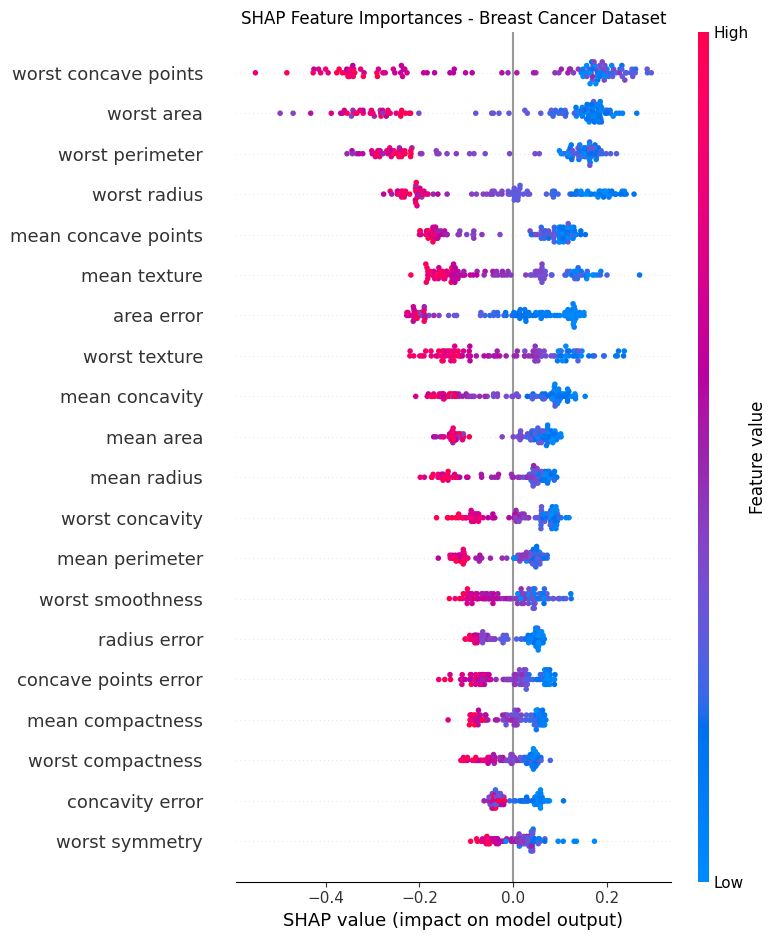

In [8]:
# Train the Final Model safely
final_model = CatBoostClassifier(
    iterations=best_config["iterations"],
    learning_rate=best_config["learning_rate"],
    depth=best_config["depth"],
    l2_leaf_reg=best_config["l2_leaf_reg"],
    loss_function="Logloss",
    verbose=False,
    random_seed=42
)

final_model.fit(X_train, y_train)

# Setup SHAP Explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Visualize the summary plot
plt.title("SHAP Feature Importances - Breast Cancer Dataset")
shap.summary_plot(shap_values, X_test, feature_names=data.feature_names)

## Ray serve

In [9]:
import requests
from ray import serve
from starlette.requests import Request

serve.start(detached=True)

@serve.deployment(num_replicas=2)
class CancerDiagnoser:
    def __init__(self, model):
        self.model = model

    async def __call__(self, request: Request):
        payload = await request.json()
        features = payload.get("features", [])

        prediction = self.model.predict([features])[0]
        probability = self.model.predict_proba([features])[0][1]

        return {
            "prediction": int(prediction),
            "malignancy_probability": round(float(probability), 4)
        }

app = CancerDiagnoser.bind(final_model)

serve.run(app, route_prefix="/predict")

print("Model deployed successfully to Ray Serve at http://localhost:8000/predict")

(ProxyActor pid=16660) INFO 2026-03-28 05:27:42,752 proxy 172.28.0.12 -- Proxy starting on node 898f9a6dcadb20088c18eb8eaabebf53fe3bd92ec8bbcf56875d218a (HTTP port: 8000).
INFO 2026-03-28 05:27:42,866 serve 14457 -- Started Serve in namespace "serve".
(ProxyActor pid=16660) INFO 2026-03-28 05:27:42,861 proxy 172.28.0.12 -- Got updated endpoints: {}.
INFO 2026-03-28 05:27:42,912 serve 14457 -- Connecting to existing Serve app in namespace "serve". New http options will not be applied.
(ServeController pid=16609) INFO 2026-03-28 05:27:42,930 controller 16609 -- Deploying new version of Deployment(name='CancerDiagnoser', app='default') (initial target replicas: 2).
(ProxyActor pid=16660) INFO 2026-03-28 05:27:42,935 proxy 172.28.0.12 -- Got updated endpoints: {Deployment(name='CancerDiagnoser', app='default'): EndpointInfo(route='/predict', app_is_cross_language=False, route_patterns=None)}.
(ProxyActor pid=16660) INFO 2026-03-28 05:27:42,947 proxy 172.28.0.12 -- Started <ray.serve._priva

Model deployed successfully to Ray Serve at http://localhost:8000/predict


## Testing

In [10]:
# Grab the first row from X_test
sample_features = X_test.iloc[0].tolist()
actual_label = y_test.iloc[0]

# Send a POST request to our Ray Serve API
response = requests.post(
    "http://localhost:8000/predict",
    json={"features": sample_features}
)

print(f"API Response: {response.json()}")
print(f"Actual Label: {actual_label} (0 = Malignant, 1 = Benign)")

API Response: {'prediction': 0, 'malignancy_probability': 0.0955}
Actual Label: 0 (0 = Malignant, 1 = Benign)


### Shutdown Ray
Now that our computations are completed safely, we shut down the Ray cluster resources.

In [11]:
ray.shutdown()